# 카테고리별 Macro F1 비교 — 독립 차트 (SchoolBridge 발표용)

**담당:** 경이  
**목적:** JSON 파일 의존 없이 하드코딩 데이터로 카테고리별 F1 비교 그래프 생성 (발표 전용)  
**기반 데이터:** KcELECTRA v3_2 (beomi/kcelectra-base) vs TF-IDF + LogReg 베이스라인  
**색상:** SchoolBridge PDF 팔레트 적용

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import platform
from pathlib import Path

# 한글 폰트 설정
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    try:
        import subprocess
        import matplotlib.font_manager as fm
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rc('font', family=prop.get_name())
    except Exception:
        pass
matplotlib.rcParams['axes.unicode_minus'] = False
print('폰트 설정 완료')

폰트 설정 완료


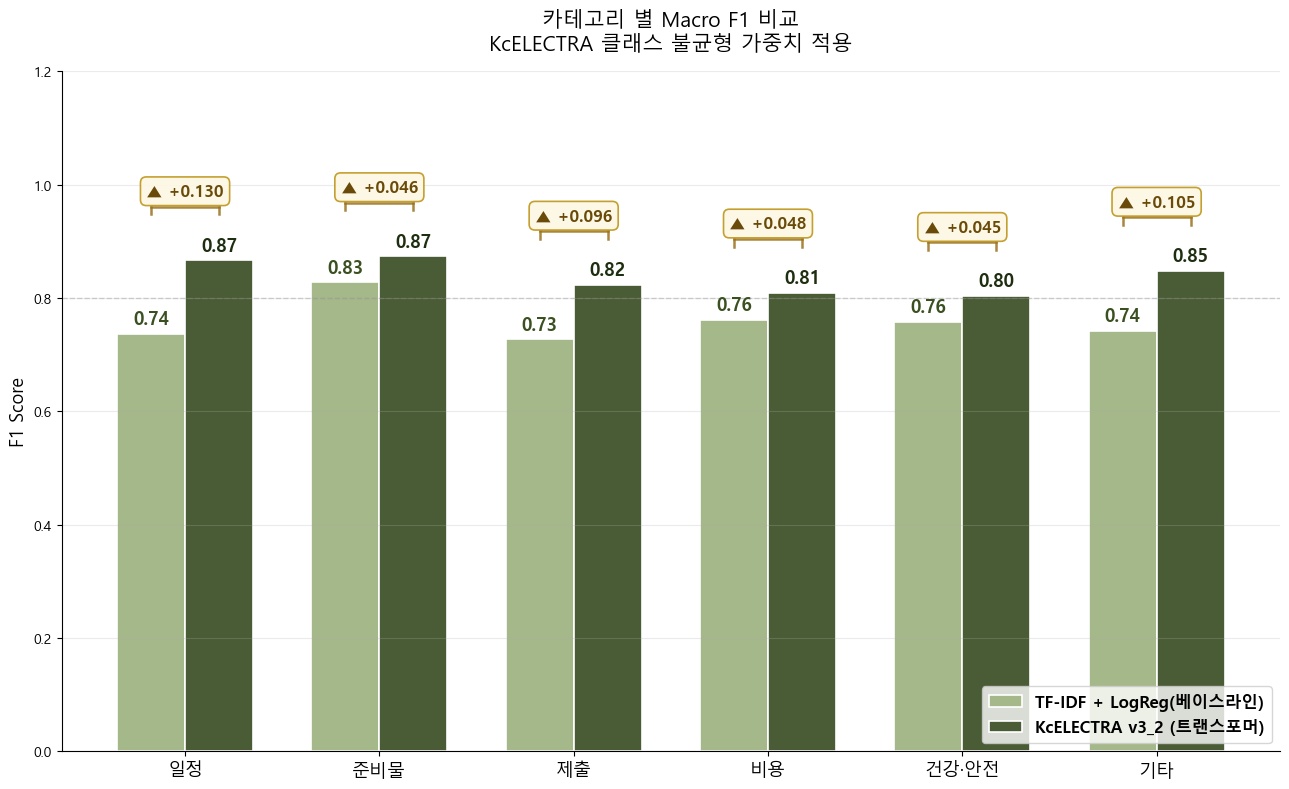

저장 완료: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260509\category_f1_comparison_schoolbridge_20260512.png


In [ ]:
# ── 데이터 하드코딩 (JSON 불필요) ────────────────────────────────
# 출처: eval_results_simple_v3_2_20260509.json / eval_results_kcelectra_v3_2_20260509.json
LABELS = ['일정', '준비물', '제출', '비용', '건강·안전', '기타']

#          일정     준비물    제출     비용    건강·안전   기타
s_f1s = [0.7368, 0.8276, 0.7273, 0.7619,  0.7581, 0.7426]  # TF-IDF + LogReg
k_f1s = [0.8665, 0.8736, 0.8233, 0.8095,  0.8034, 0.8479]  # KcELECTRA v3_2

# ── SchoolBridge PDF 팔레트 ──────────────────────────────────────
COLOR_BASE = '#a5b88a'   # 세이지 올리브  — TF-IDF + LogReg 베이스라인
COLOR_KC   = '#4a5c35'   # 다크 포레스트 그린 — KcELECTRA v3_2
COLOR_ANN  = '#9a7220'   # 웜 앰버 골드   — 향상 폭 브래킷

x = np.arange(len(LABELS))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 8))

bars1 = ax.bar(x - w/2, s_f1s, w,
               label='TF-IDF + LogReg(베이스라인)',
               color=COLOR_BASE, edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + w/2, k_f1s, w,
               label='KcELECTRA v3_2 (트랜스포머)',
               color=COLOR_KC, edgecolor='white', linewidth=1.2)

# 막대 위 숫자 레이블 (발표용 — 크고 굵게)
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.010,
            f'{h:.2f}', ha='center', va='bottom',
            fontsize=13, color='#3a5020', fontweight='bold')# 막대 위 숫자 크기 _막대 위 숫자 굵기
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.010,
            f'{h:.2f}', ha='center', va='bottom',
            fontsize=13, color='#1e2e10', fontweight='bold')

# ── 향상 폭 브래킷 표시 ──────────────────────────────────────────
for i, (s, k) in enumerate(zip(s_f1s, k_f1s)):
    delta = k - s
    bar1_cx = x[i] - w/2
    bar2_cx = x[i] + w/2
    bracket_y = max(s, k) + 0.095  # 큰 숫자 레이블 위 여백 확보

    # 가로 브래킷 선
    ax.plot([bar1_cx, bar2_cx], [bracket_y, bracket_y],
            color=COLOR_ANN, lw=1.8, alpha=0.85)
    # 좌우 세로 틱
    tick_h = 0.014
    for cx in [bar1_cx, bar2_cx]:
        ax.plot([cx, cx], [bracket_y - tick_h, bracket_y],
                color=COLOR_ANN, lw=1.8, alpha=0.85)

    # 향상 폭 배지 (발표용 — 크고 굵게) # 향상 폭 배지 숫자 크기	
    ax.text(x[i], bracket_y + 0.012, f'▲ +{delta:.3f}',
            ha='center', va='bottom', fontsize=12,
            color='#6a4a08', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='#fdf8e4', edgecolor='#c09820',
                      alpha=0.92, linewidth=1.2))

# ── 축·제목·레이아웃 ─────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=13) 
ax.set_ylim(0, 1.20)
ax.set_ylabel('F1 Score', fontsize=13)
ax.set_title(
    '카테고리 별 Macro F1 비교\nKcELECTRA 클래스 불균형 가중치 적용',
    fontsize=15, pad=16
)

# 범례 굵게
legend = ax.legend(fontsize=12, loc='lower right')#범례 크기
for text in legend.get_texts():
    text.set_fontweight('bold') # 범례 텍스트

ax.axhline(y=0.8, color='#888', linestyle='--', alpha=0.35, linewidth=1)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

# 저장 경로
_nb_dir = Path('.').resolve()
_out_dir = (_nb_dir.parent / 'data' / '20260509'
            if _nb_dir.name == 'notebooks'
            else _nb_dir)
_out_dir.mkdir(parents=True, exist_ok=True)
out_path = _out_dir / 'category_f1_comparison_schoolbridge_20260512.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_path}')

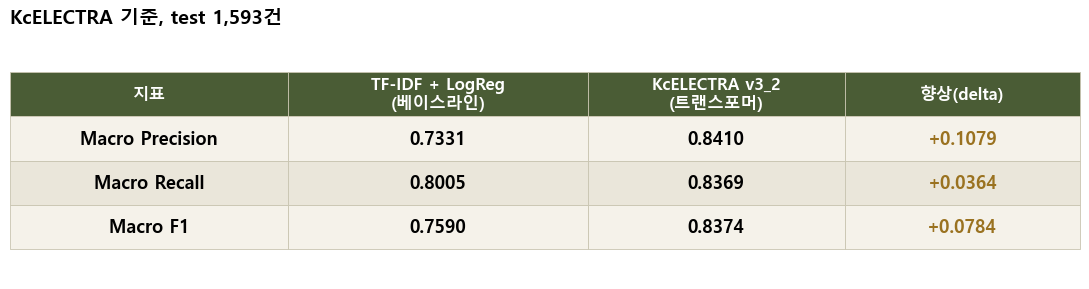

저장 완료: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260509\metrics_table_schoolbridge_20260512.png


In [6]:
# ── 메인 비교 결과 테이블 ─────────────────────────────────────────
# 제목: KcELECTRA 기준, test 1,593건
# 열: 지표 / TF-IDF + LogReg(베이스라인) / KcELECTRA v3_2 / 향상(delta)

col_labels = ['지표', 'TF-IDF + LogReg\n(베이스라인)', 'KcELECTRA v3_2\n(트랜스포머)', '향상(delta)']
col_widths = [0.26, 0.28, 0.24, 0.22]

rows = [
    ['Macro Precision', '0.7331', '0.8410', '+0.1079'],
    ['Macro Recall',    '0.8005', '0.8369', '+0.0364'],
    ['Macro F1',        '0.7590', '0.8374', '+0.0784'],
]

# SchoolBridge 팔레트
HEADER_BG   = '#4a5c35'   # 다크 포레스트 그린 헤더
ROW_ODD_BG  = '#f5f2ea'   # 홀수 행 — 크림
ROW_EVEN_BG = '#eae6da'   # 짝수 행 — 연한 베이지
DELTA_COLOR = '#9a7220'   # 향상 값 — 웜 앰버

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.axis('off')
ax.set_title('KcELECTRA 기준, test 1,593건',
             fontsize=14, fontweight='bold', pad=14, loc='left')

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    colWidths=col_widths,
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.scale(1, 2.6)

for (r, c), cell in table.get_celld().items():
    cell.set_linewidth(0.6)
    cell.set_edgecolor('#c8c4b0')
    if r == 0:  # 헤더
        cell.set_facecolor(HEADER_BG)
        cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(12)
    else:       # 데이터 행
        cell.set_facecolor(ROW_ODD_BG if r % 2 == 1 else ROW_EVEN_BG)
        cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(13)
        if c == 3:  # 향상 열
            cell.get_text().set_color(DELTA_COLOR)

plt.tight_layout()

_nb_dir = Path('.').resolve()
_out_dir = (_nb_dir.parent / 'data' / '20260509'
            if _nb_dir.name == 'notebooks'
            else _nb_dir)
_out_dir.mkdir(parents=True, exist_ok=True)
out_path = _out_dir / 'metrics_table_schoolbridge_20260512.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_path}')